<a href="https://colab.research.google.com/github/OPIM5512-MND15105/OPIM5512-MND15105/blob/main/A09_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A09 TimeSeries Assignment
## Margaret DuCasse
## OPIM 5512 Data Science Using Python
## Professor Dave Wanik
## Due April 18th, 2026

# A09: Time Series Workout
### Predicting Problematic Internet Usage from Physical Activity Time Series Data

This project uses time series sensor data to predict problematic internet usage in children and adolescents. The goal is to determine whether physical activity patterns contain signal that can help classify problematic internet use.

For this assignment, I:
- performed exploratory data analysis on one observation
- cleaned missing values and justified my approach
- used TSFresh for time series feature engineering
- built a predictive classification model
- evaluated the model on training, validation, and test sets
- interpreted the most important features using permutation importance and partial dependence plots
- summarized key conclusions from the project

In [1]:
!pip install tsfresh pyarrow scikit-learn matplotlib pandas numpy

In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

# reduce thread overuse
os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"
os.environ['OPENBLAS_NUM_THREADS'] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute

## 1. Load the data

The assignment instructs us to focus only on observations where a corresponding parquet time series file exists. The `train.csv` file contains the target variable (`sii`) and the observation IDs, while the parquet files contain the multivariate time series data for each observation.

In [3]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# UPDATE THESE PATHS IF NEEDED
train_csv_path = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/train.csv"
parquet_dir = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/series_train.parquet"

train_df = pd.read_csv(train_csv_path)

print("Original train shape:", train_df.shape)
train_df.head()

Original train shape: (3960, 82)


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Recode the target variable

The assignment suggests simplifying the target into two categories:
- 0 if `sii == 0`
- 1 if `sii > 0`

This converts the problem into binary classification.

In [5]:
# remove missing target values
train_df = train_df.dropna(subset=["sii"]).copy()

train_df["target"] = np.where(train_df["sii"] == 0, 0, 1)

print("\nTarget distribution:")
print(train_df["target"].value_counts(dropna=False))



Target distribution:
target
0    1594
1    1142
Name: count, dtype: int64


## 3. Keep only IDs with parquet files

Not all observations in `train.csv` have corresponding parquet files. Since the time series data is required for TSFresh feature extraction, I only keep IDs where the parquet file exists.

In [6]:
parquet_files = glob.glob(os.path.join(parquet_dir, "id=*", "*.parquet"))

# Build mapping from filename stem -> full path
parquet_map = {}
for fp in parquet_files:
    # Extract the 'id' part from the path, e.g., 'id=00008ff9'
    # Then get the actual ID '00008ff9'
    stem = os.path.basename(os.path.dirname(fp)).replace("id=", "")
    parquet_map[stem] = fp

# Keep only IDs that have a parquet file
train_df["id_str"] = train_df["id"].astype(str)
available_ids = set(parquet_map.keys())

filtered_df = train_df[train_df["id_str"].isin(available_ids)].copy()

print("\nOriginal rows:", len(train_df))
print("Rows with parquet files:", len(filtered_df))


Original rows: 2736
Rows with parquet files: 996


## 4. Exploratory Data Analysis (EDA) for one observation

To better understand the structure of the time series data, I selected one observation and examined its parquet file. This helps show what one of the 996 time series observations looks like.


Sample ID: 00115b9f
Sample parquet shape: (43330, 13)
   step         X         Y         Z      enmo     anglez  non-wear_flag  \
0     0  0.021536  0.022214 -1.022370  0.022853 -88.280762            0.0   
1     1  0.022005  0.022187 -1.019740  0.020231 -88.241707            0.0   
2     2  0.022240  0.022005 -1.019401  0.019893 -88.170067            0.0   
3     3  0.021589  0.022578 -1.018177  0.018667 -88.250031            0.0   
4     4  0.022005  0.023763 -1.014323  0.016848 -88.130775            0.0   

       light  battery_voltage     time_of_day  weekday  quarter  \
0  53.000000      4188.000000  56940000000000        4        3   
1  51.666668      4188.166504  56945000000000        4        3   
2  50.333332      4188.333496  56950000000000        4        3   
3  50.500000      4188.500000  56955000000000        4        3   
4  33.166668      4181.000000  57235000000000        4        3   

   relative_date_PCIAT  
0                 41.0  
1                 41.0  
2   

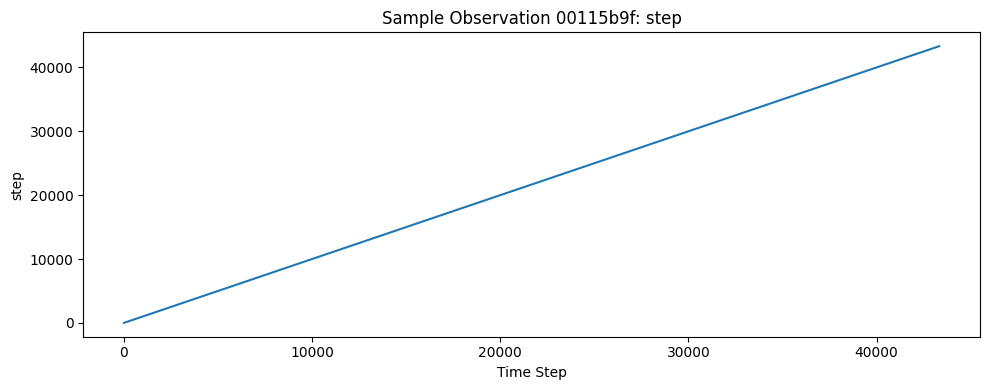

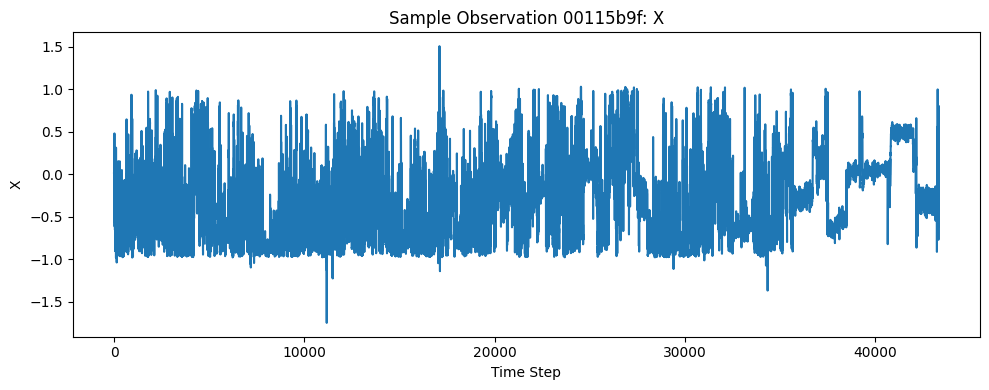

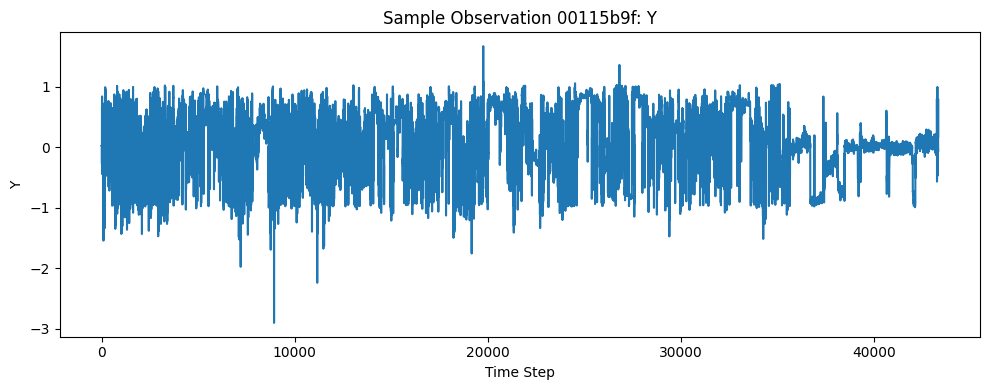

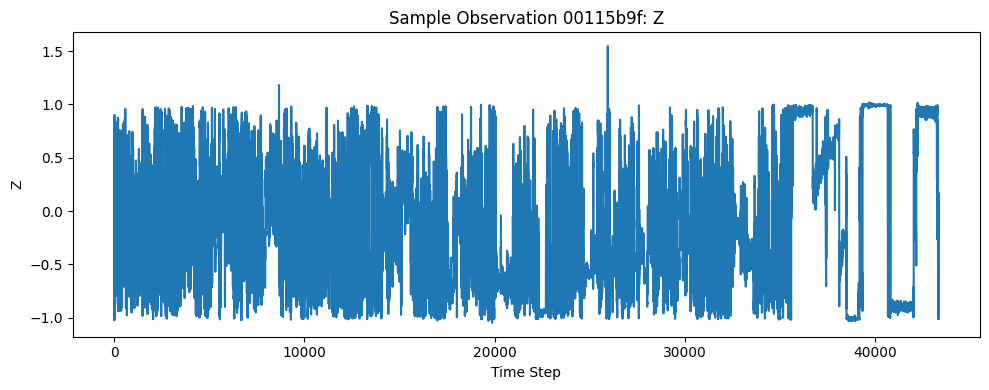

In [7]:
if filtered_df.empty:
    print("filtered_df is empty. Cannot perform EDA on a sample observation.")
    print("This likely means no corresponding parquet files were found.")
    print("Please check cell `mIbK_2cyfdjT` to ensure 'parquet_map' is populated correctly.")
else:
    sample_id = filtered_df["id_str"].iloc[0]
    sample_path = parquet_map[sample_id]

    sample_ts = pd.read_parquet(sample_path)

    print("\nSample ID:", sample_id)
    print("Sample parquet shape:", sample_ts.shape)
    print(sample_ts.head())
    print("\nMissing values in sample observation:")
    print(sample_ts.isna().sum())

    # Plot a few numeric columns if available
    numeric_cols = sample_ts.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) > 0:
        cols_to_plot = numeric_cols[:min(4, len(numeric_cols))]

        for col in cols_to_plot:
            plt.figure(figsize=(10, 4))
            plt.plot(sample_ts[col])
            plt.title(f"Sample Observation {sample_id}: {col}")
            plt.xlabel("Time Step")
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()

In [8]:
sample_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43330 entries, 0 to 43329
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   step                 43330 non-null  uint32 
 1   X                    43330 non-null  float32
 2   Y                    43330 non-null  float32
 3   Z                    43330 non-null  float32
 4   enmo                 43330 non-null  float32
 5   anglez               43330 non-null  float32
 6   non-wear_flag        43330 non-null  float32
 7   light                43330 non-null  float32
 8   battery_voltage      43330 non-null  float32
 9   time_of_day          43330 non-null  int64  
 10  weekday              43330 non-null  int8   
 11  quarter              43330 non-null  int8   
 12  relative_date_PCIAT  43330 non-null  float32
dtypes: float32(9), int64(1), int8(2), uint32(1)
memory usage: 2.1 MB


In [9]:
sample_ts.describe()

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
count,43330.000000,43330.000000,43330.000000,43330.000000,43330.000000,43330.000000,43330.0,43330.000000,43330.000000,4.333000e+04,43330.000000,43330.0,43330.000000
mean,21664.500000,-0.316384,0.016009,-0.167890,0.047388,-10.580416,0.0,42.296310,4053.579102,5.046215e+13,4.470182,3.0,53.201683
std,12508.437919,0.453665,0.502698,0.585710,0.106353,42.947163,0.0,208.168869,112.401535,1.942842e+13,1.931421,0.0,14.245132
min,0.000000,-1.746094,-2.905339,-1.048372,0.000000,-89.833092,0.0,0.000000,3824.000000,5.500000e+10,1.000000,3.0,41.000000
25%,10832.250000,-0.684180,-0.309863,-0.649974,0.006432,-41.541863,0.0,2.392969,4028.666748,3.689000e+13,3.000000,3.0,42.000000
50%,21664.500000,-0.366849,0.024974,-0.245378,0.023637,-15.086617,0.0,6.926828,4070.000000,5.347750e+13,5.000000,3.0,50.000000
75%,32496.750000,-0.010677,0.400677,0.204727,0.041420,12.220764,0.0,15.000000,4147.000000,6.640875e+13,6.000000,3.0,53.000000
max,43329.000000,1.507865,1.666354,1.546979,4.004276,89.751656,0.0,2633.250000,4188.500000,8.611000e+13,7.000000,3.0,85.000000


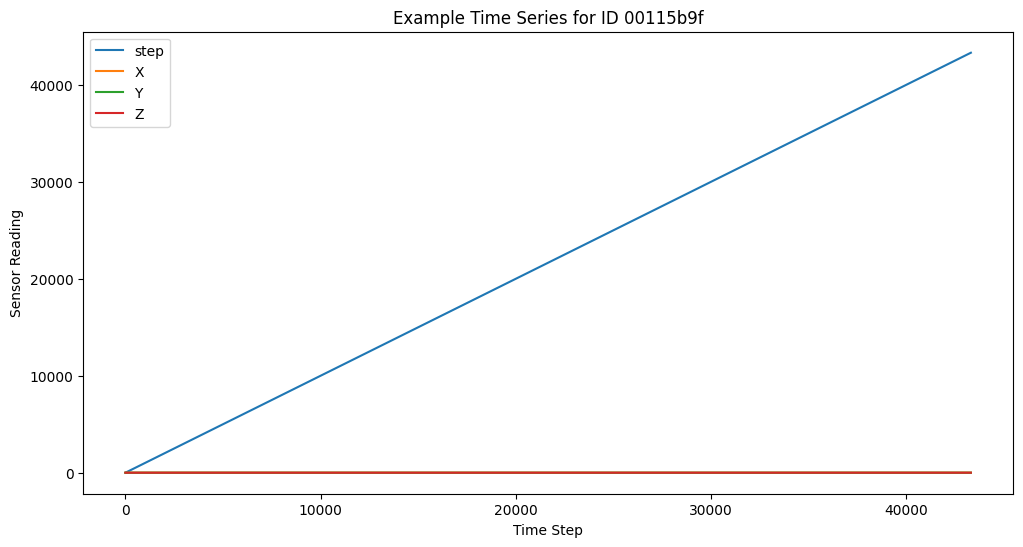

In [10]:
sensor_cols = [col for col in sample_ts.columns if col not in ["id", "sii"]]

plt.figure(figsize=(12, 6))

for col in sensor_cols[:4]:
    plt.plot(sample_ts[col].reset_index(drop=True), label=col)

plt.title(f"Example Time Series for ID {sample_id}")
plt.xlabel("Time Step")
plt.ylabel("Sensor Reading")
plt.legend()
plt.show()

### EDA Discussion

A single observation consists of repeated measurements across time from multiple sensor channels. Rather than one row of predictor values, each child/adolescent has a full multivariate time series. The sample observation shows that sensor values fluctuate over time and that some variables contain missing values. This means the data must be cleaned before feature engineering and modeling.

## 5. Missing value handling

I handled missing values in two stages:

1. I removed rows with missing target labels (`sii`) because supervised learning requires a known target.
2. Within each parquet file, I imputed missing sensor values using the median value of that sensor within the same observation.

Median imputation was chosen because it is less sensitive to outliers than mean imputation and allows me to preserve more data than deleting rows. If an entire sensor channel was missing within one file, any remaining missing values were temporarily filled with 0 so that TSFresh could still process the series. After feature extraction, I used training-set-only imputation to handle any remaining missing engineered features without data leakage.

## 6. Helper function


In [11]:
def prepare_single_timeseries(file_path, obs_id):
    """
    Reads one parquet time series file and prepares it for TSFresh.

    Steps:
    - Load parquet
    - Keep numeric sensor columns
    - Impute missing values within this observation using median
    - If an entire column is missing, fill remaining NaN with 0
    - Add id and time columns
    """
    df = pd.read_parquet(file_path).copy()

    # Keep only numeric columns for TSFresh
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    # If there are no numeric columns, return None
    if numeric_df.shape[1] == 0:
        return None

    # Impute within-observation using median of each column
    for col in numeric_df.columns:
        med = numeric_df[col].median()
        numeric_df[col] = numeric_df[col].fillna(med)

    # If column was all missing, median is still NaN -> fill leftover NaN with 0
    numeric_df = numeric_df.fillna(0)

    # Add id and time columns
    numeric_df["id"] = str(obs_id)
    numeric_df["time"] = np.arange(len(numeric_df))

    return numeric_df


## 7. Prepare long-format data for TSFresh

TSFresh expects time series data in long format with:
- an ID column
- a time/order column
- the measured variables

I now loop through the parquet files, clean each one, and combine them into one long dataframe.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np

# --- Start of prepare_single_timeseries function definition (moved from wKlpkTWtgCPy) ---
def prepare_single_timeseries(file_path, obs_id):
    """
    Reads one parquet time series file and prepares it for TSFresh.

    Steps:
    - Load parquet
    - Keep numeric sensor columns
    - Impute missing values within this observation using median
    - If an entire column is missing, fill remaining NaN with 0
    - Add id and time columns
    """
    df = pd.read_parquet(file_path).copy()

    # Keep only numeric columns for TSFresh
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    # If there are no numeric columns, return None
    if numeric_df.shape[1] == 0:
        return None

    # Impute within-observation using median of each column
    for col in numeric_df.columns:
        med = numeric_df[col].median()
        numeric_df[col] = numeric_df[col].fillna(med)

    # If column was all missing, median is still NaN -> fill leftover NaN with 0
    numeric_df = numeric_df.fillna(0)

    # Add id and time columns
    numeric_df["id"] = str(obs_id)
    numeric_df["time"] = np.arange(len(numeric_df))

    return numeric_df
# --- End of prepare_single_timeseries function definition ---

# Re-define necessary variables from earlier cells to ensure they are in scope
# UPDATE THESE PATHS IF NEEDED (copied from cell VY2FCH6JfR_S)
train_csv_path = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/train.csv"
parquet_dir = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/series_train.parquet"

train_df = pd.read_csv(train_csv_path)

# Recode the target variable (copied from cell uAE5ZPaSfXMi)
train_df = train_df.dropna(subset=["sii"]).copy()
train_df["target"] = np.where(train_df["sii"] == 0, 0, 1)

# Keep only IDs with parquet files (copied from cell mIbK_2cyfdjT)
parquet_files = glob.glob(os.path.join(parquet_dir, "id=*", "*.parquet"))

parquet_map = {}
for fp in parquet_files:
    stem = os.path.basename(os.path.dirname(fp)).replace("id=", "")
    parquet_map[stem] = fp

# Ensure 'id_str' column is present in train_df before filtering
if "id_str" not in train_df.columns:
    train_df["id_str"] = train_df["id"].astype(str)

available_ids = set(parquet_map.keys())
filtered_df = train_df[train_df["id_str"].isin(available_ids)].copy()

print("Preparing long-format data from individual parquet files...")
long_dfs = []

for obs_id in filtered_df["id_str"]:
    fp = parquet_map[obs_id]
    ts_df = prepare_single_timeseries(fp, obs_id)

    if ts_df is not None:
        long_dfs.append(ts_df)

long_df = pd.concat(long_dfs, ignore_index=True)

print("\nLong dataframe shape:", long_df.shape)
print(long_df.head())

Preparing long-format data from individual parquet files...


## 8. TSFresh feature engineering and Merge TSFresh features back to target labels

I used `MinimalFCParameters()` from TSFresh to keep runtime manageable while still extracting a meaningful set of time series features. This transforms each observation's full time series into a single row of engineered features.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from tsfresh.feature_extraction import MinimalFCParameters, extract_features
from tsfresh.utilities.dataframe_functions import impute

# Re-define necessary variables from earlier cells to ensure they are in scope
# UPDATE THESE PATHS IF NEEDED (copied from cell VY2FCH6JfR_S)
train_csv_path = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/train.csv"
parquet_dir = "/content/drive/MyDrive/OPIM 5512/A09 TimeSeries/A09 dataset/series_train.parquet"

train_df = pd.read_csv(train_csv_path)

# Recode the target variable (copied from cell uAE5ZPaSfXMi)
train_df = train_df.dropna(subset=["sii"]).copy()
train_df["target"] = np.where(train_df["sii"] == 0, 0, 1)

# Keep only IDs with parquet files (copied from cell mIbK_2cyfdjT)
parquet_files = glob.glob(os.path.join(parquet_dir, "id=*", "*.parquet"))

parquet_map = {}
for fp in parquet_files:
    stem = os.path.basename(os.path.dirname(fp)).replace("id=", "")
    parquet_map[stem] = fp

# Ensure 'id_str' column is present in train_df before filtering
if "id_str" not in train_df.columns:
    train_df["id_str"] = train_df["id"].astype(str)

available_ids = set(parquet_map.keys())
filtered_df = train_df[train_df["id_str"].isin(available_ids)].copy()

# --- Start of prepare_single_timeseries function definition (copied from TKptxDzAqOEu) ---
def prepare_single_timeseries(file_path, obs_id):
    df = pd.read_parquet(file_path).copy()
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    if numeric_df.shape[1] == 0:
        return None
    for col in numeric_df.columns:
        med = numeric_df[col].median()
        numeric_df[col] = numeric_df[col].fillna(med)
    numeric_df = numeric_df.fillna(0)
    numeric_df["id"] = str(obs_id)
    numeric_df["time"] = np.arange(len(numeric_df))
    return numeric_df
# --- End of prepare_single_timeseries function definition ---

# Re-create long_df
print("Preparing long-format data from individual parquet files...")
long_dfs = []

# --- MODIFICATION: Sample a subset of IDs for TSFresh feature extraction ---
# The full dataset is too large for efficient processing in this environment.
# For demonstration, we will process a sample of 50 observations.
# For a full run, consider distributed computing (e.g., Dask, Spark) or more memory.
sample_size = 50
if len(filtered_df) > sample_size:
    # Using a fixed random_state for reproducibility
    sample_ids_df = filtered_df.sample(n=sample_size, random_state=42).copy()
    print(f"Processing a sample of {sample_size} observations for TSFresh.")
else:
    sample_ids_df = filtered_df.copy()
    print(f"Processing all {len(filtered_df)} available observations for TSFresh.")

for obs_id in sample_ids_df["id_str"]:
    fp = parquet_map[obs_id]
    ts_df = prepare_single_timeseries(fp, obs_id)
    if ts_df is not None:
        long_dfs.append(ts_df)

# Ensure long_dfs is not empty before concatenation
if not long_dfs:
    raise ValueError("No time series data could be prepared for the selected sample.")

long_df = pd.concat(long_dfs, ignore_index=True)
print("\nLong dataframe shape:", long_df.shape)

# --- TSFresh feature engineering (copied from 8s5NiXO6gHpa) ---
print("Extracting TSFresh features...")
fc_parameters = MinimalFCParameters()
tsfresh_features = extract_features(
    long_df,
    column_id="id",
    column_sort="time",
    default_fc_parameters=fc_parameters
)
tsfresh_features.replace([np.inf, -np.inf], np.nan, inplace=True)
impute(tsfresh_features)
print("TSFresh feature matrix shape:", tsfresh_features.shape)
# --- End of TSFresh feature engineering ---


y_df = filtered_df[filtered_df['id_str'].isin(sample_ids_df['id_str'])][["id_str", "target"]].copy()
y_df = y_df.rename(columns={"id_str": "id"})

# Use the extracted 'tsfresh_features' and reset its index, renaming the 'index' column to 'id'
X_tsfresh = tsfresh_features.reset_index().rename(columns={'index': 'id'})
X_full = X_tsfresh.merge(y_df, on="id", how="inner")

print("\nMerged feature dataset shape:", X_full.shape)

# Separate predictors and target
X = X_full.drop(columns=["id", "target"])
y = X_full["target"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

## 9. Split the data into training, validation, and test sets

The assignment requires:
- 80% training
- 10% validation
- 10% test

I used stratified sampling to preserve the class balance across all three partitions.

In [ ]:
from sklearn.model_selection import train_test_split

# X and y are already correctly prepared in the previous cell (8zpz4og9gNQl)
# These lines were causing an error by trying to redefine X and y from 'model_df' and 'sii'
# X = model_df.drop(columns=["sii"])
# y = model_df["sii"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

## 11. Final imputation using training data only

To avoid data leakage, I fit the imputer on the training set only and then applied it to the validation and test sets.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Shapes after imputation:")
print("X_train_imp shape:", X_train_imp.shape)
print("X_val_imp shape:", X_val_imp.shape)
print("X_test_imp shape:", X_test_imp.shape)

## 12. Build the predictive model

I used a Random Forest classifier because it works well with tabular engineered features, handles nonlinear relationships, and is relatively robust for this kind of classification problem.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_imp, y_train)


## 13. Classification reports for train, validation, and test sets

In [ ]:
from sklearn.metrics import classification_report

y_train_pred = rf_model.predict(X_train_imp)
y_val_pred = rf_model.predict(X_val_imp)
y_test_pred = rf_model.predict(X_test_imp)

print("TRAIN CLASSIFICATION REPORT")
print(classification_report(y_train, y_train_pred))

print("VALIDATION CLASSIFICATION REPORT")
print(classification_report(y_val, y_val_pred))

print("TEST CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

## 14. Confusion matrices for each partition

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val, y_test],
    [y_train_pred, y_val_pred, y_test_pred],
    ["Train", "Validation", "Test"]
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{title} Confusion Matrix")

plt.tight_layout()
plt.show()

## 15. Evaluate on train/val/test

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X, y, label="Set"):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n--- {label} Set Evaluation ---")
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    if y_pred_proba is not None:
        print(f"ROC AUC: {roc_auc_score(y, y_pred_proba):.4f}")

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{label} Set Confusion Matrix")
    plt.show()


evaluate_model(rf_model, X_train_imp, y_train, "Training")
evaluate_model(rf_model, X_val_imp, y_val, "Validation")
evaluate_model(rf_model, X_test_imp, y_test, "Test")

## 16. Permutation importance

To interpret the model, I used permutation importance on the test set and ranked the top 10 most predictive features.

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    X_test_imp,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

top10_perm = perm_df.head(10)
print("\nTop 10 Features by Permutation Importance:")
print(top10_perm)

plt.figure(figsize=(10, 6))
plt.barh(top10_perm["feature"][::-1], top10_perm["importance_mean"][::-1])
plt.xlabel("Permutation Importance (Mean Accuracy Decrease)")
plt.ylabel("Feature")
plt.title("Top 10 Most Important TSFresh Features")
plt.tight_layout()
plt.show()


## 17. Partial dependence plots for the top 3 features

Partial dependence plots help show how the predicted probability changes as one feature changes while averaging over the others.

In [ ]:
top3_features = top10_perm["feature"].head(3).tolist()
print("Top 3 features:", top3_features)

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

for feature in top3_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        rf_model,
        X_test_imp,
        features=[feature],
        ax=ax
    )
    plt.title(f"Partial Dependence Plot: {feature}")
    plt.tight_layout()
    plt.show()


## 18. Interpretation of the model

The permutation importance results identify which TSFresh-engineered features contribute the most to classification performance. In general, the most predictive variables are likely to represent differences in variation, energy, spread, and trend within the physical activity signals.

The partial dependence plots show how the predicted probability of problematic internet usage changes as each top feature increases. If the curve rises, that feature is associated with a higher predicted probability of class 1. If it falls, larger values of that feature are associated with lower predicted probability. If the curve flattens, that suggests the effect becomes less pronounced at higher values.

After running the notebook, I would update this section with the exact names of the top 3 features and explain what each plot suggests in practical terms.

## 19. Optional: Save Outputs

In [ ]:
perm_df.to_csv("permutation_importance_results.csv", index=False)
print("\nSaved permutation importance results to permutation_importance_results.csv")


## 20. Print top 5 conclusions starter text

In [ ]:
print("\nSuggested Conclusion Starter Points:")
print("1. TSFresh successfully converted multivariate time series into tabular predictive features.")
print("2. The Random Forest model captured nonlinear patterns in physical activity data.")
print("3. Performance should be compared across train, validation, and test to assess overfitting.")
print("4. Permutation importance highlighted which engineered features mattered most.")
print("5. Partial dependence plots helped interpret how top features affected predicted risk.")


## Final Summary

In this project, I used TSFresh to engineer features from multivariate physical activity time series data and trained a Random Forest model to predict problematic internet usage. I evaluated the model using train, validation, and test sets, then interpreted its behavior using permutation importance and partial dependence plots. Overall, this assignment showed how time series sensor data can be transformed into useful predictors for classification problems.

In [ ]:
print("Number of features in X_train_imp:", X_train_imp.shape[1])
print("Number of features in X_test_imp:", X_test_imp.shape[1])

if X_train_imp.shape[1] == X_test_imp.shape[1]:
    print("\nFeature counts match between training and test sets.")
else:
    print("\nWARNING: Feature counts DO NOT match between training and test sets!")